## Imports

In [1]:
import torch
from torchvision import transforms
import torchvision
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn as nn

## Check Device

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [3]:
print(f"Using device: {device}")

Using device: mps


## Visualization

In [4]:
# For Visualization (we only use to Tensor and NO normalization)
train_transform_viz = transforms.Compose([transforms.ToTensor()])

In [5]:
train_viz = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=train_transform_viz)

In [6]:
train_viz_loader = torch.utils.data.DataLoader(train_viz, batch_size=32, shuffle=True)

In [7]:
data_iter = iter(train_viz_loader)
images, labels = next(data_iter)

In [8]:
images.shape        # this means [batch_size=32, channels=3, height=32, width=32]

torch.Size([32, 3, 32, 32])

In [9]:
labels.shape       # this means 32 images, all with 1 label each

torch.Size([32])

In [10]:
# This helps to stitch all 32 images into 1 full image, reducing the 4th dim into to normal 3 dim (channel, height, width)
grid = torchvision.utils.make_grid(images)

In [11]:
# matplotlib requires (H, W, 3), permute changes (3, H, W) ---> (H, W, 3) for matplotlib

# permute(1,2,0) means new dimension 0 == old dimension 1
# new dimension 1 == old dimension 2
# new dimension 2 = old dimension 0

images_grid = grid.permute(1, 2, 0)

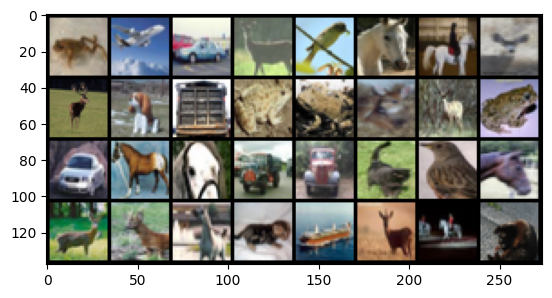

In [12]:
plt.imshow(images_grid)

## Data Augmentation

In [13]:
train_transform = transforms.Compose([transforms.RandomHorizontalFlip(),      # data augmentation
                                        transforms.RandomCrop(32, padding=4), # data augmentation
                                        transforms.ToTensor(),
                                        transforms.Normalize((0.4914, 0.4822, 0.4465),  # CIFAR-10 mean
                                                            (0.2023, 0.1994, 0.2010))   # CIFAR-10 std
                                        ])

In [14]:
test_transform = transforms.Compose([transforms.ToTensor(),
                                    transforms.Normalize((0.4914, 0.4822, 0.4465),
                                                        (0.2023, 0.1994, 0.2010))
                                    ])

In [15]:
train = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=train_transform)
val = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=test_transform)
test  = torchvision.datasets.CIFAR10(root='../../data', train=False, download=True, transform=test_transform)

In [16]:
train, _ = torch.utils.data.random_split(train, [0.8, 0.2])
_, val = torch.utils.data.random_split(val, [0.8, 0.2])

In [17]:
train_loader = torch.utils.data.DataLoader(train, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val, batch_size=32, shuffle=False)
test_loader = torch.utils.data.DataLoader(test, batch_size=32, shuffle=False)

## Training

In [ ]:
from model import ResNet

save_path = '../../models/resnet/model.pth'
best_val_accuracy = 0
patience = 5
epochs_without_improvement = 0
total_epochs = 100
model = ResNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, min_lr=1e-5) # Reduce learning_rate if no improvements after 3 epochs

for epoch in range(total_epochs):
    
    # --------- TRAINING --------- 
    model.train()                           # training mode
    for images, labels in tqdm(train_loader):
        optimizer.zero_grad()               # clear the residual gradient from the previous batch 
        images = images.to(device)          # send the images to gpu/cpu
        labels = labels.to(device)          # send the labels to gpu/cpu
        outputs = model(images)             # forward pass, images go through resnet layers, outputs 10 scores per image
        loss = criterion(outputs, labels)   # compares the 10 scores against the real labels, gives a single loss number
        loss.backward()                     # backpropagation --> pytorch calculates how much each each weight contributed to the loss
        optimizer.step()                    # update weights using those gradients
    
    # --------- EVALUATION ------------
    model.eval()                                                # evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():                                       # we stop tracking gradient here
        for images, labels in val_loader:
            images = images.to(device)                          # send val images to gpu/cpu
            labels = labels.to(device)                          # send corresponding val labels to gpu/cpu
            outputs = model(images)                             # forward pass through current resnset model with weights, output 10 scores per image
            _, predicted = torch.max(outputs, 1)                # torch.max() gives class with highest score (gives actual score and our prediction)
            total += labels.size(0)                             # labels is 1D tensor (32,) -- meaning 32 images in a batch, 1 label each, size(0) gets 32
            correct += (predicted == labels).sum().item()       # add correctly predicted labels into 'correct' and sum them

    val_accuracy = 100 * correct / total                        # get validation accuracy percentage
    scheduler.step(val_accuracy)                                # Ask scheduler to check if validation has improved

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        epochs_without_improvement = 0
        torch.save(model.state_dict(), save_path)  # save best model
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break
    
    print(f"Epoch {epoch+1}/{total_epochs}, Loss: {loss.item():.4f}, Val Accuracy: {val_accuracy:.2f}%, LR: {optimizer.param_groups[0]['lr']:.6f}")

100%|██████████| 1250/1250 [00:29<00:00, 42.60it/s]


Epoch 1/100, Loss: 1.0442, Val Accuracy: 46.92%, LR: 0.001000


100%|██████████| 1250/1250 [00:29<00:00, 42.82it/s]


Epoch 2/100, Loss: 1.0821, Val Accuracy: 52.07%, LR: 0.001000


100%|██████████| 1250/1250 [00:29<00:00, 42.98it/s]


...

Epoch 36/100, Loss: 0.4889, Val Accuracy: 84.15%, LR: 0.000010


100%|██████████| 1250/1250 [00:31<00:00, 40.12it/s]


Epoch 37/100, Loss: 0.4409, Val Accuracy: 84.07%, LR: 0.000010


100%|██████████| 1250/1250 [00:31<00:00, 39.55it/s]


Early stopping at epoch 38


In [19]:
# Load best model and test
model.load_state_dict(torch.load(save_path))
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 81.03%


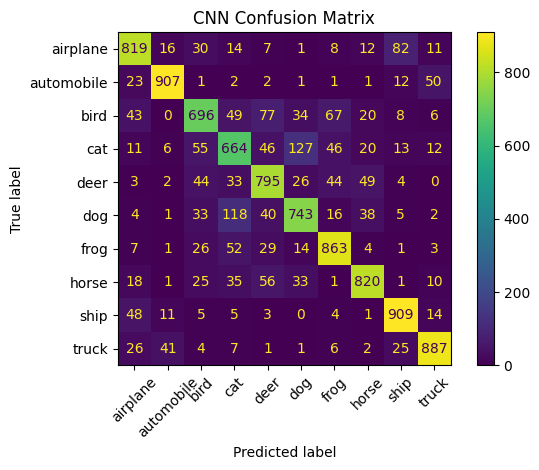

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
            'dog', 'frog', 'horse', 'ship', 'truck']

all_predictions = []
all_labels = []

model.load_state_dict(torch.load('../../models/resnet/model.pth'))
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)                                    # gets the class with highest score for each image, throws away actual score value, predicted keeps the class index
        all_predictions.extend(predicted.cpu().numpy())                         # .cpu() moves tensors from MPS to CPU memory, sklearn can't read from GPU, .numpy means we then convert it to numpy
        all_labels.extend(labels.cpu().numpy())                                 # extend just adds all the items from the batch into the list one by one

cm = confusion_matrix(all_labels, all_predictions)                              # sklearn takes the true labels and predictions and builds a 10x10 matrix counting how many times each true class got predicted as each class
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)      # wraps the raw matrix in display settings, attaches the class names
disp.plot(xticks_rotation=45)                                                   # rotates the x axis labels so they don't overlap
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.show()